In [1]:
# --- Standard library ---
import sys                                 # system params
from pathlib import Path                   # OO paths

# --- Third-party packages ---
try:
    import numpy as np                     # numerical arrays
except ImportError as e:
    raise RuntimeError("Missing 'numpy'. Install:\n  pip install numpy") from e

try:
    import pandas as pd                    # tabular data
except ImportError as e:
    raise RuntimeError("Missing 'pandas'. Install:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt        # plotting
except ImportError as e:
    raise RuntimeError("Missing 'matplotlib'. Install:\n  pip install matplotlib") from e

try:
    import statsmodels.nonparametric.smoothers_lowess  # required by detect_jumps_lowess
except ImportError as e:
    raise RuntimeError("Missing 'statsmodels'. Install:\n  pip install statsmodels") from e

# --- Doris library ---
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.stations.trend import fit_piecewise_trend
    from doris.analysis.stations.discontinuities import (
        detect_jumps_sliding_window,
        detect_jumps_lowess,
    )
    from doris.output.tables import Col, save_latex_table
except ImportError as e:
    raise RuntimeError(
        "Cannot import doris. Make sure 'src/' is in sys.path.\n"
        "Original error: " + str(e)
    )


### Paths and constants

In [2]:
# --- Dataset selection ---
PRODUCT       = "stcd"               # product, e.g. "stcd", "eop"
SOLUTION      = "gop25wd04"          # solution version
STATION       = "LICB"               # station code, e.g. "LICB", "CADB"
TREND_VARIANT = "weighted_multiseg"  # trend variant used for detrending

COMPONENTS = ["dE", "dN", "dU"]

# --- Input data ---
#   "aper"  -> aperiodic residuals  (trend + periodicity removed)
#   "detr"  -> detrended residuals  (only trend removed)
INPUT_TYPE = "detr"

# --- Detection parameters ---

# Method 1: sliding window
window_size = 40       # W: window length [samples]
shift       = 40       # s: offset between windows [samples]
sw_mode     = "t_test"  # "heuristic" or "t_test"
sigma_mult  = 1.0      # threshold = sigma_mult * sigma  (heuristic only)
sw_alpha    = 0.05     # significance level               (t_test only)

# Method 2: LOWESS + derivative
frac_lowess   = 0.2    # smoothing fraction (smaller = less smooth)
lw_mode       = "z_test"  # "heuristic" or "z_test"
k_sigma_slope = 2.0    # threshold = k_sigma_slope * sigma_slope  (heuristic only)
min_slope_abs = 3.0    # minimum absolute threshold [mm/yr]
lw_alpha      = 0.05   # significance level                        (z_test only)

# --- Paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR     = PROJECT_ROOT / "data" / PRODUCT / SOLUTION
EXPORT_DIR   = DATA_DIR / "exports" / STATION.lower()
IMAGES_DIR   = PROJECT_ROOT / "LaTeX" / "images" / "results" / "stations" / STATION.lower()
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

TABLES_REL_DIR = Path("results") / "stations" / STATION.lower()
TABLES_DIR = PROJECT_ROOT / "LaTeX" / "tables" / TABLES_REL_DIR
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PRINT_TABLE_PREVIEW = True  # print generated LaTeX source while saving tables

BASE_NAME  = f"{SOLUTION}_{PRODUCT}_{STATION.lower()}"
APER_CSV   = EXPORT_DIR / f"{BASE_NAME}_aper_{TREND_VARIANT}.csv"
IMAGE_NAME = BASE_NAME

print("Project: ", PROJECT_ROOT)
print("Data:    ", EXPORT_DIR)
print("Input:   ", INPUT_TYPE, "(\'aper\' = no trend/periodicity, \'detr\' = no trend)")


Project:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
Data:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb
Input:    detr ('aper' = no trend/periodicity, 'detr' = no trend)


In [3]:
# --- Load residuals ---
if not APER_CSV.exists():
    candidates = sorted(EXPORT_DIR.glob("*_aper_*.csv"))
    hint = "\n".join(f"  - {p.name}" for p in candidates) or "  (no files found)"
    raise FileNotFoundError(
        f"File not found:\n  {APER_CSV}\n\nAvailable files:\n{hint}"
    )

df_aper = pd.read_csv(APER_CSV)

# Column prefix: "aper_dE" for aperiodic, "res_dE" for detrended-only
col = "aper" if INPUT_TYPE == "aper" else "res"

print(f"\u2714\ufe0f Loaded {len(df_aper)} rows from {APER_CSV.name}")
print(f"Using columns: {col}_dE / {col}_dN / {col}_dU")
df_aper.head()


✔️ Loaded 543 rows from gop25wd04_stcd_licb_aper_weighted_multiseg.csv
Using columns: res_dE / res_dN / res_dU


,Date,dE,dN,dU,sE,sN,sU,year,fit_dE,res_dE,...,fit_dU,res_dU,seg_dU,t_year,res_dE_std,res_dN_std,res_dU_std,aper_dE,aper_dN,aper_dU
0,2015-01-07 12:00:00,333.1,279.0,-3.4,8.2,3.4,4.8,2015.017808,332.601115,0.498885,...,-4.183761,0.783761,0,0.000000,0.035812,-0.594433,0.094721,2.566434,-4.131528,-0.727806
1,2015-01-14 12:00:00,346.4,276.7,5.1,7.8,3.4,4.9,2015.036986,333.038814,13.361186,...,-4.253971,9.353971,0,0.019178,1.002787,-0.953329,1.145929,15.138477,-6.709047,7.895903
2,2015-01-21 12:00:00,305.3,275.2,-1.7,8.6,3.6,5.2,2015.056164,333.476512,-28.176512,...,-4.324181,2.624181,0,0.038356,-2.119974,-1.200833,0.320464,-26.713250,-8.486566,1.239112
3,2015-01-28 12:00:00,308.6,275.0,10.3,8.4,3.5,5.0,2015.075342,333.914210,-25.314210,...,-4.394391,14.694391,0,0.057534,-1.904789,-1.267323,1.800976,-24.184548,-8.964085,13.400845
4,2015-02-04 12:00:00,325.1,278.2,-1.4,8.2,3.4,5.1,2015.094521,334.351908,-9.251908,...,-4.464601,3.064601,0,0.076713,-0.697242,-0.860394,0.374485,-8.470972,-6.041604,1.879885


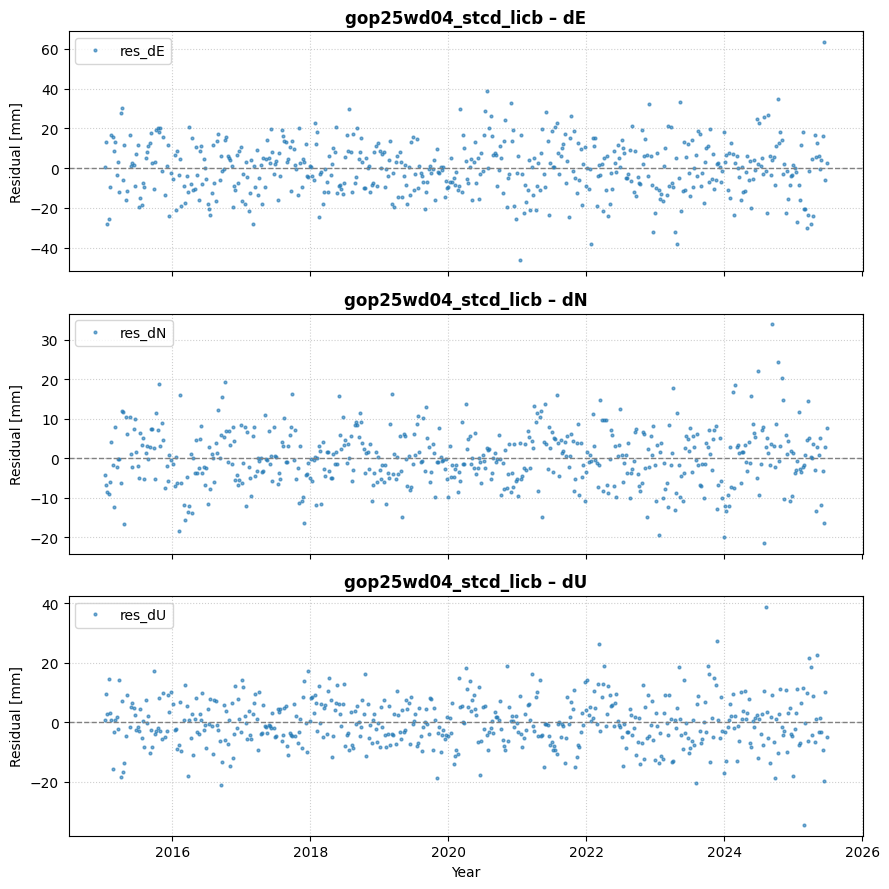

In [4]:
# --- Plot input residuals ---
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_aper[f"{col}_{comp}"]
    ax.plot(df_aper["year"], y, ".", ms=4, alpha=0.6, label=f"{col}_{comp}")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{BASE_NAME} \u2013 {comp}", fontweight="bold")
    ax.set_ylabel("Residual [mm]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()


### Method 1: Sliding window

In [5]:
# Sliding-window jump detection
years = df_aper["year"].to_numpy()
sw_results = {}

for comp in COMPONENTS:
    y = df_aper[f"{col}_{comp}"].fillna(0).to_numpy()
    sw_results[comp] = detect_jumps_sliding_window(
        years, y,
        window_size=window_size, shift=shift,
        threshold_mode=sw_mode, sigma_mult=sigma_mult, alpha=sw_alpha,
    )

print("Sliding-window detection done.")
for comp in COMPONENTS:
    r = sw_results[comp]
    print(f"  {comp}: {len(r)} jump(s),  threshold={r.threshold:.2f} mm")


Sliding-window detection done.
  dE: 58 jump(s),  threshold=13.29 mm
  dN: 74 jump(s),  threshold=7.18 mm
  dU: 83 jump(s),  threshold=8.15 mm


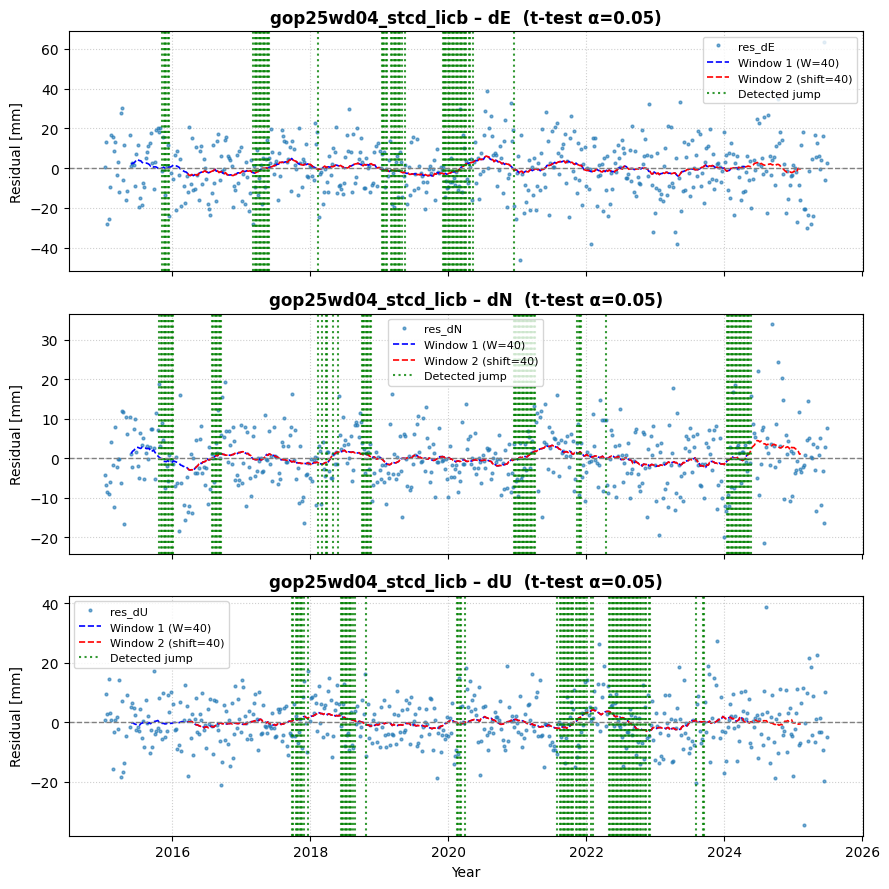

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_aper[f"{col}_{comp}"].to_numpy()
    x = df_aper["year"].to_numpy()
    r = sw_results[comp]
    e = r.extras

    ax.plot(x, y, ".", ms=4, alpha=0.6, label=f"{col}_{comp}")
    ax.plot(e["years1"], e["mu1"], "b--", lw=1.2, label=f"Window 1 (W={e['window_size']})")
    ax.plot(e["years2"], e["mu2"], "r--", lw=1.2, label=f"Window 2 (shift={e['shift']})")

    first = True
    for xv in r.jumps:
        ax.axvline(xv, color="green", linestyle=":", alpha=0.8,
                   label="Detected jump" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    label = f"\u03c3\u00d7{sigma_mult}" if sw_mode == "heuristic" else f"t-test \u03b1={sw_alpha}"
    ax.set_title(f"{BASE_NAME} \u2013 {comp}  ({label})", fontweight="bold")
    ax.set_ylabel("Residual [mm]")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Year")
plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_sliding_window.pdf", bbox_inches="tight", dpi=150)
plt.show()


### Method 2: LOWESS smoothing + derivative

In [7]:
# LOWESS derivative jump detection
lw_results = {}

for comp in COMPONENTS:
    y = df_aper[f"{col}_{comp}"].fillna(0).to_numpy()
    lw_results[comp] = detect_jumps_lowess(
        years, y,
        frac=frac_lowess,
        threshold_mode=lw_mode, k_sigma=k_sigma_slope,
        min_abs=min_slope_abs, alpha=lw_alpha,
    )

print(f"LOWESS detection done.  frac={frac_lowess}, k={k_sigma_slope}, min={min_slope_abs}")
for comp in COMPONENTS:
    r = lw_results[comp]
    print(f"  {comp}: {len(r)} jump(s),  threshold={r.threshold:.2f} mm/yr")


LOWESS detection done.  frac=0.2, k=2.0, min=3.0
  dE: 3 jump(s),  threshold=6.38 mm/yr
  dN: 22 jump(s),  threshold=3.07 mm/yr
  dU: 22 jump(s),  threshold=3.40 mm/yr


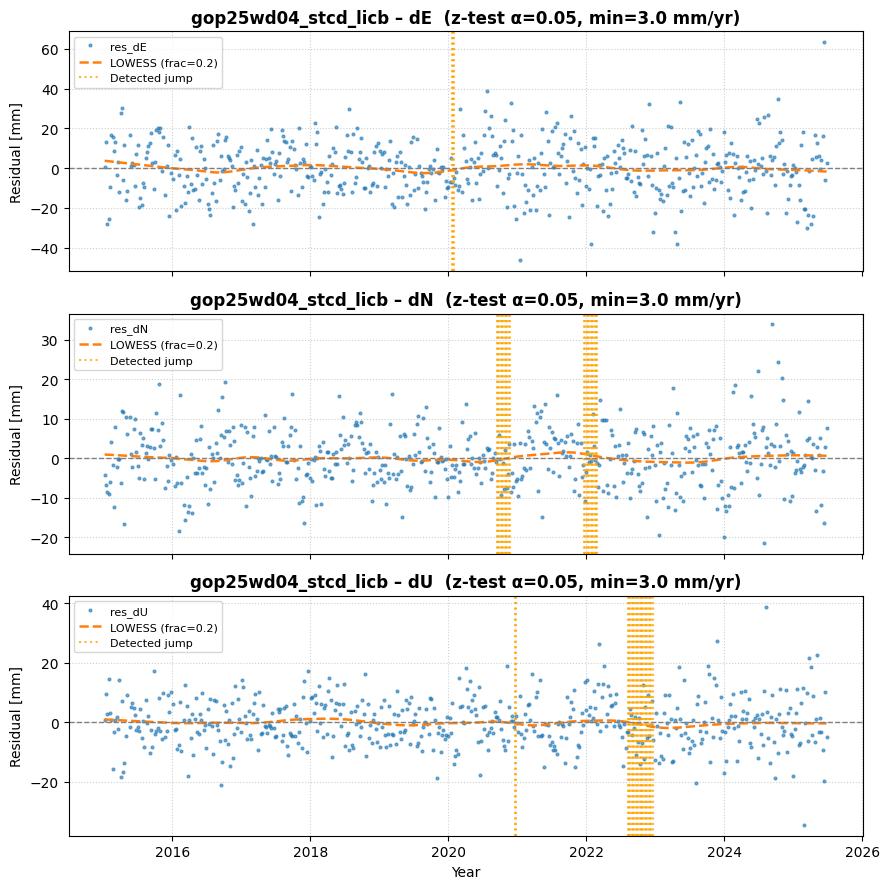

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y = df_aper[f"{col}_{comp}"].fillna(0).to_numpy()
    r = lw_results[comp]
    e = r.extras

    ax.plot(years, y, ".", ms=4, alpha=0.6, label=f"{col}_{comp}")
    ax.plot(years, e["smoothed"], "--", lw=1.8, label=f"LOWESS (frac={e['frac']})")

    first = True
    for xv in r.jumps:
        ax.axvline(xv, color="orange", ls=":", alpha=0.8,
                   label="Detected jump" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    label = f"k={k_sigma_slope}, min={min_slope_abs}\u00a0mm/yr" if lw_mode == "heuristic" \
            else f"z-test \u03b1={lw_alpha}, min={min_slope_abs}\u00a0mm/yr"
    ax.set_title(f"{BASE_NAME} \u2013 {comp}  ({label})", fontweight="bold")
    ax.set_ylabel("Residual [mm]")
    ax.grid(True, ls=":", alpha=0.6)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)

axes[-1].set_xlabel("Year")
plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_lowess_derivate.pdf", bbox_inches="tight", dpi=150)
plt.show()


### Method 3: Doris – piecewise linear trend (BIC)

The **doris** library function `fit_piecewise_trend` searches for breakpoints automatically using the BIC criterion.  
Detected breakpoints correspond to potential jumps or trend changes.

In [9]:
# BIC-driven piecewise linear trend – detect breakpoints
bic_results = {}

for comp in COMPONENTS:
    y = df_aper[f"{col}_{comp}"].fillna(0).values

    # max_segments=None: add breakpoints as long as BIC decreases
    result = fit_piecewise_trend(years, y, max_segments=None)
    bic_results[comp] = result

    print(f"{comp}: {result.n_segments} segment(s), BIC={result.bic:.1f}, "
          f"breakpoints={[f'{bp:.3f}' for bp in result.breakpoints]}")


dE: 1 segment(s), BIC=2822.0, breakpoints=[]
dN: 1 segment(s), BIC=2152.4, breakpoints=[]
dU: 1 segment(s), BIC=2290.4, breakpoints=[]


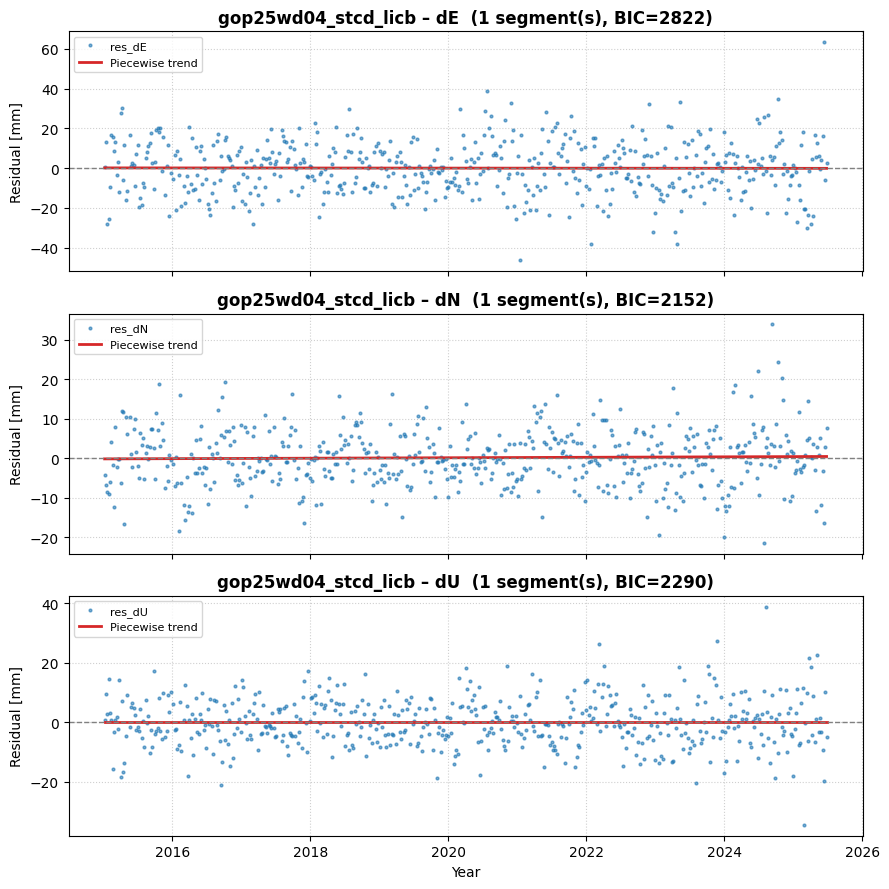

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, comp in zip(axes, COMPONENTS):
    y      = df_aper[f"{col}_{comp}"].fillna(0).to_numpy()
    result = bic_results[comp]

    ax.plot(years, y, ".", ms=4, alpha=0.6, label=f"{col}_{comp}")

    # piecewise fitted line (segment by segment)
    breakpoints = result.breakpoints
    boundaries  = [-np.inf] + list(breakpoints) + [np.inf]
    for i in range(len(boundaries) - 1):
        mask = (years > boundaries[i]) & (years <= boundaries[i + 1])
        if mask.any():
            ax.plot(years[mask], result.fitted[mask], "-", lw=2, color="tab:red",
                    label="Piecewise trend" if i == 0 else None)

    # vertical lines at breakpoints
    first = True
    for bp in breakpoints:
        ax.axvline(bp, color="purple", ls="--", alpha=0.85,
                   label="Breakpoint (doris)" if first else None)
        first = False

    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(
        f"{BASE_NAME} \u2013 {comp}  ({result.n_segments}\u00a0segment(s), BIC={result.bic:.0f})",
        fontweight="bold",
    )
    ax.set_ylabel("Residual [mm]")
    ax.grid(True, ls=":", alpha=0.6)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)

axes[-1].set_xlabel("Year")
plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_doris_piecewise.pdf", bbox_inches="tight", dpi=150)
plt.show()
